In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import deque
from sklearn import datasets
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
sns.set_theme()

# Подготовка набора данных

Ирисы Фишера — набор данных, содержащий записи о 150 экземплярах ириса, по 50 экземпляров из трёх видов.

Включает в себя следующие столбцы:
- `sepal_length` - длина наружной доли околоцветника (чашелистика) в сантиметрах;
- `sepal_width` - ширина наружной доли околоцветника (чашелистика) в сантиметрах;
- `petal_length` - длина внутренней доли околоцветника (лепестка) в сантиметрах;
- `petal_width` - ширина внутренней доли околоцветника (лепестка) в сантиметрах;
- `species` - вид ириса (setosa, virginica или versicolor).

In [2]:
iris_raw = datasets.load_iris()
iris = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)
iris.rename(columns={
    "sepal length (cm)": "sepal_length", "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length", "petal width (cm)": "petal_width"
}, inplace=True)
iris["species"] = iris_raw.target_names[iris_raw.target]
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


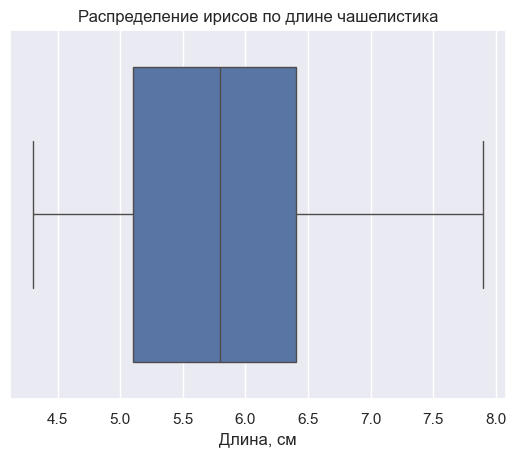

In [4]:
sns.boxplot(iris, x="sepal_length").set(
    title="Распределение ирисов по длине чашелистика", xlabel="Длина, см"
);

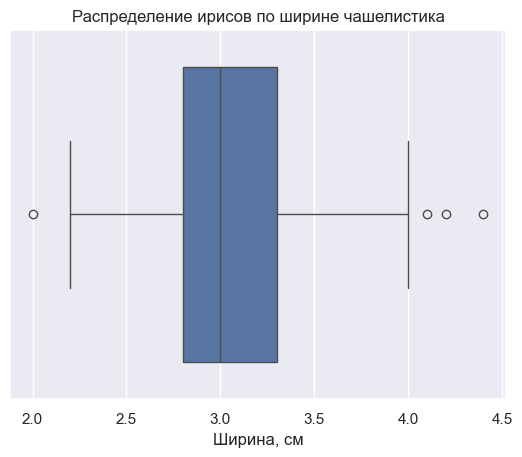

In [5]:
sns.boxplot(iris, x="sepal_width").set(
    title="Распределение ирисов по ширине чашелистика", xlabel="Ширина, см"
);

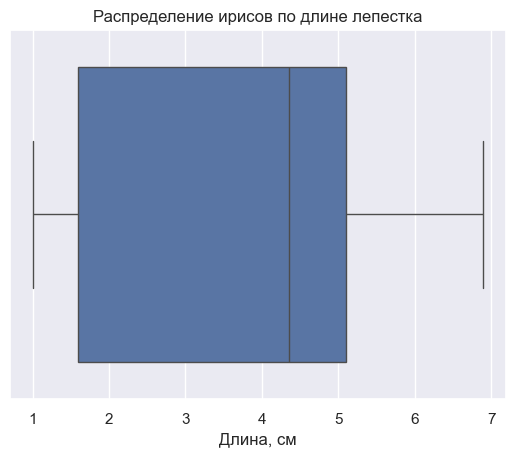

In [6]:
sns.boxplot(iris, x="petal_length").set(
    title="Распределение ирисов по длине лепестка", xlabel="Длина, см"
);

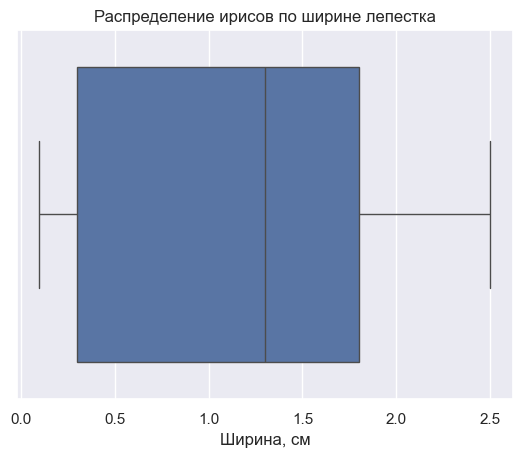

In [7]:
sns.boxplot(iris, x="petal_width").set(
    title="Распределение ирисов по ширине лепестка", xlabel="Ширина, см"
);

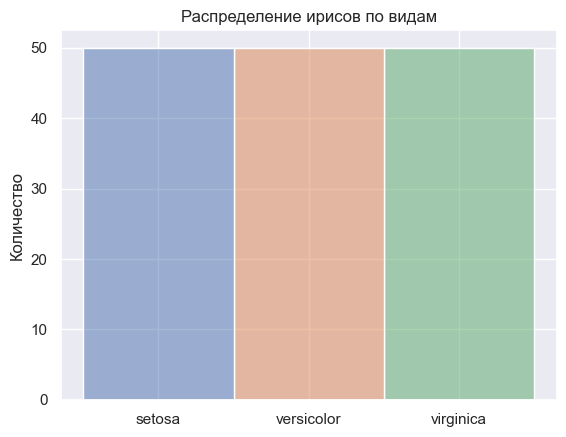

In [8]:
sns.histplot(iris, x="species", hue="species", legend=None).set(
    title="Распределение ирисов по видам", xlabel="", ylabel="Количество"
);

In [9]:
(y_true := iris.species)

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [10]:
(X := iris.drop(columns="species"))

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [11]:
standard_scaler = StandardScaler()
X = standard_scaler.fit_transform(X)
X[:10]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ],
       [-0.53717756,  1.93979142, -1.16971425, -1.05217993],
       [-1.50652052,  0.78880759, -1.34022653, -1.18381211],
       [-1.02184904,  0.78880759, -1.2833891 , -1.3154443 ],
       [-1.74885626, -0.36217625, -1.34022653, -1.3154443 ],
       [-1.14301691,  0.09821729, -1.2833891 , -1.44707648]])

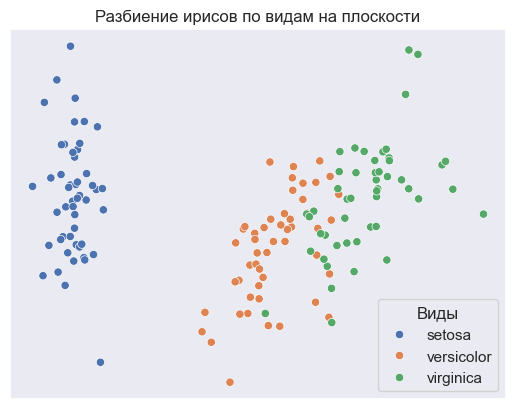

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true).set(
    title="Разбиение ирисов по видам на плоскости", xticks=[], yticks=[]
)
plt.legend(title="Виды", loc="lower right");

# Своя реализация KMeans

In [13]:
class MyKMeans:
    def __init__(self, n_clusters=8, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        
        if self.n_clusters <= 0:
            raise ValueError("Ошибка: n_clusters должен быть положительным числом")
        
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
    
    def __init_centroids(self, X):
        random_generator = np.random.RandomState(self.random_state)
        indices = random_generator.choice(X.shape[0], size=self.n_clusters, replace=False)
        return X[indices].copy()
    
    def __calculate_labels(self, X, centers):
        distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2) ** 2
        return np.argmin(distances, axis=1)
    
    def __calculate_centers(self, X, labels):
        n_features = X.shape[1]
        centers = np.zeros((self.n_clusters, n_features))
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                centers[k] = np.mean(cluster_points, axis=0)
            else:
                random_generator = np.random.RandomState(self.random_state)
                centers[k] = X[random_generator.randint(0, X.shape[0])]
        return centers
    
    def fit(self, X):
        X = np.array(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        n_samples, n_features = X.shape
        if n_samples < self.n_clusters:
            raise ValueError(f"Ошибка: количество образцов {n_samples} меньше числа кластеров {self.n_clusters}")
        
        centers = self.__init_centroids(X)
        
        for iteration in range(self.max_iter):
            old_centers = centers.copy()
            
            labels = self.__calculate_labels(X, centers)
            
            centers = self.__calculate_centers(X, labels)
            
            center_shift = np.linalg.norm(centers - old_centers, axis=1).max()
            if center_shift < self.tol:
                break
        
        self.cluster_centers_ = centers
        self.labels_ = self.__calculate_labels(X, centers)
        self.n_iter_ = iteration + 1
        
        distances = np.linalg.norm(X - self.cluster_centers_[self.labels_], axis=1)
        self.inertia_ = np.sum(distances ** 2)
        
        return self
    
    def fit_predict(self, X):
        self.fit(X)
        return self.labels_
    
    def predict(self, X):
        if self.cluster_centers_ is None:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X = np.array(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        if X.shape[1] != self.cluster_centers_.shape[1]:
            raise ValueError(f"Ошибка: ожидается {self.cluster_centers_.shape[1]} признаков, а получено {X.shape[1]}")
        
        return self.__calculate_labels(X, self.cluster_centers_)

# Сравнение библиотечной реализации со своей

In [14]:
kmeans1 = KMeans(n_clusters=3, random_state=5)
y_kmeans1 = kmeans1.fit_predict(X)
adjusted_rand_score(y_true, y_kmeans1)

0.645147003482001

In [15]:
kmeans2 = MyKMeans(n_clusters=3, random_state=0)
y_kmeans2 = kmeans2.fit_predict(X)
adjusted_rand_score(y_true, y_kmeans2)

0.645147003482001

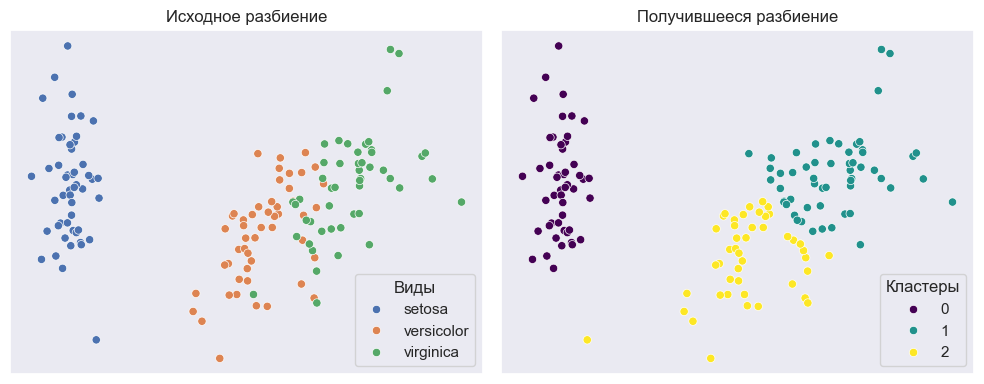

In [16]:
_, ax = plt.subplots(ncols=2, figsize=(10, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, ax=ax[0]).set(
    title="Исходное разбиение", xticks=[], yticks=[]
)
ax[0].legend(title="Виды", loc="lower right")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_kmeans1, palette="viridis", ax=ax[1]).set(
    title="Получившееся разбиение", xticks=[], yticks=[]
)
ax[1].legend(title="Кластеры", loc="lower right")
plt.tight_layout();

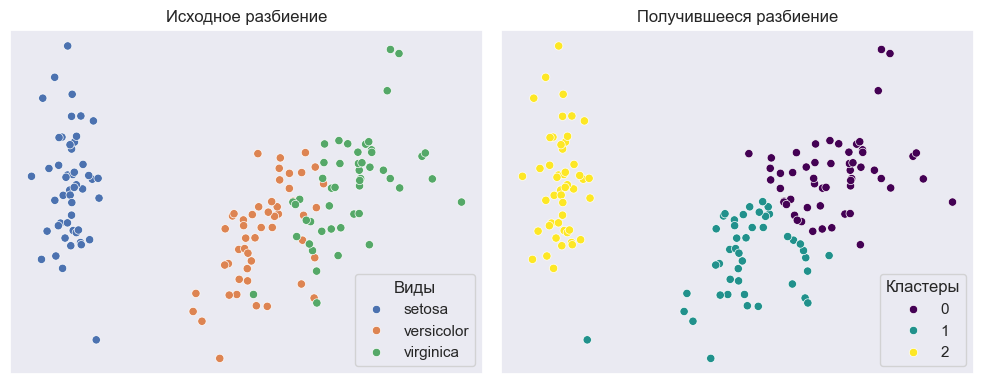

In [17]:
_, ax = plt.subplots(ncols=2, figsize=(10, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, ax=ax[0]).set(
    title="Исходное разбиение", xticks=[], yticks=[]
)
ax[0].legend(title="Виды", loc="lower right")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_kmeans2, palette="viridis", ax=ax[1]).set(
    title="Получившееся разбиение", xticks=[], yticks=[]
)
ax[1].legend(title="Кластеры", loc="lower right")
plt.tight_layout();

In [19]:
kmeans1.n_iter_

7

In [20]:
kmeans2.n_iter_

6

In [21]:
kmeans1.inertia_

140.90153181202444

In [22]:
kmeans2.inertia_

np.float64(140.90153181202442)

# Своя реализация DBSCAN

In [23]:
class MyDBSCAN:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        
        self.labels_ = None
        self.core_sample_indices_ = None
        self.components_ = None
        self.n_features_in_ = None
        self.n_clusters_ = 0
    
    def fit(self, X):
        X = np.array(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        self.n_features_in_ = X.shape[1]
        n_samples = X.shape[0]
        
        distances = np.linalg.norm(X[:, np.newaxis] - X, axis=2)
        
        neighbors = [np.where(distances[i] <= self.eps)[0] for i in range(n_samples)]
        
        core_mask = np.array([len(neighbors[i]) >= self.min_samples for i in range(n_samples)])
        self.core_sample_indices_ = np.where(core_mask)[0]
        self.components_ = X[self.core_sample_indices_]
        
        labels = np.full(n_samples, -1, dtype=int)
        current_cluster = 0
        
        for i in range(n_samples):
            if labels[i] != -1 or not core_mask[i]:
                continue
            
            queue = deque([i])
            labels[i] = current_cluster
            
            while queue:
                point = queue.popleft()
                
                for neighbor in neighbors[point]:
                    if labels[neighbor] == -1:
                        labels[neighbor] = current_cluster
                        if core_mask[neighbor]:
                            queue.append(neighbor)
            
            current_cluster += 1
        
        self.labels_ = labels
        self.n_clusters_ = len(np.unique(labels[labels != -1]))
        
        return self
    
    def fit_predict(self, X):
        self.fit(X)
        return self.labels_
    
    def predict(self, X):
        if self.core_sample_indices_ is None or self.labels_ is None:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X = np.array(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Ошибка: ожидается {self.n_features_in_} признаков, а получено {X.shape[1]}")
        
        distances_to_cores = np.linalg.norm(X[:, np.newaxis] - self.components_, axis=2)
        
        preds = []
        for i in range(X.shape[0]):
            core_neighbors = np.where(distances_to_cores[i] <= self.eps)[0]
            if len(core_neighbors) == 0:
                preds.append(-1)
            else:
                nearest_core = core_neighbors[np.argmin(distances_to_cores[i, core_neighbors])]
                core_index = self.core_sample_indices_[nearest_core]
                preds.append(self.labels_[core_index])
        
        return np.array(preds)

# Сравнение библиотечной реализации со своей

In [24]:
dbscan1 = DBSCAN(eps=0.65, min_samples=5)
y_dbscan1 = dbscan1.fit_predict(X)
adjusted_rand_score(y_true, y_dbscan1)

0.4991943216979547

In [25]:
dbscan2 = MyDBSCAN(eps=0.65, min_samples=5)
y_dbscan2 = dbscan2.fit_predict(X)
adjusted_rand_score(y_true, y_dbscan2)

0.4991943216979547

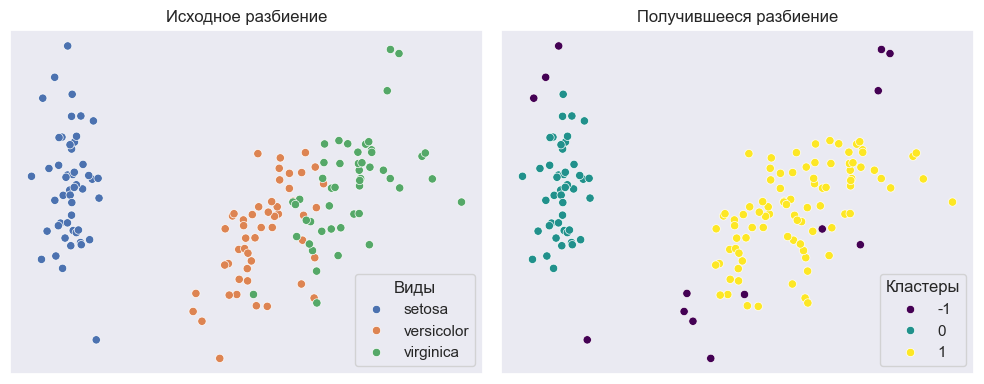

In [26]:
_, ax = plt.subplots(ncols=2, figsize=(10, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, ax=ax[0]).set(
    title="Исходное разбиение", xticks=[], yticks=[]
)
ax[0].legend(title="Виды", loc="lower right")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_dbscan1, palette="viridis", ax=ax[1]).set(
    title="Получившееся разбиение", xticks=[], yticks=[]
)
ax[1].legend(title="Кластеры", loc="lower right")
plt.tight_layout();

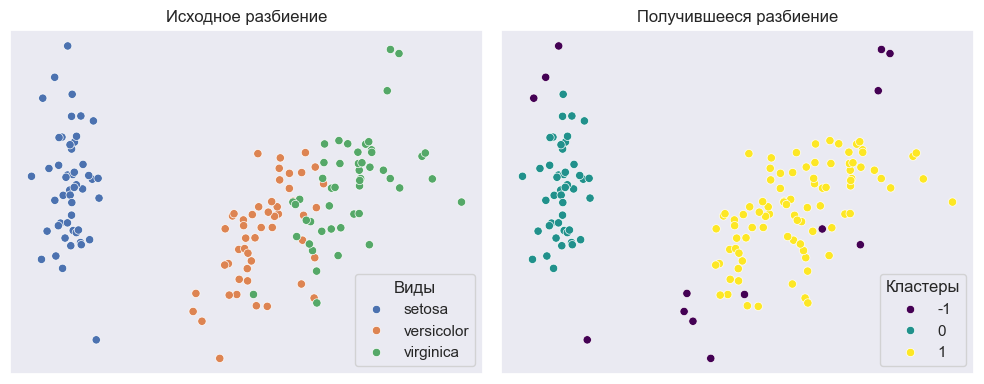

In [27]:
_, ax = plt.subplots(ncols=2, figsize=(10, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, ax=ax[0]).set(
    title="Исходное разбиение", xticks=[], yticks=[]
)
ax[0].legend(title="Виды", loc="lower right")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_dbscan2, palette="viridis", ax=ax[1]).set(
    title="Получившееся разбиение", xticks=[], yticks=[]
)
ax[1].legend(title="Кластеры", loc="lower right")
plt.tight_layout();